Kích thước dữ liệu gốc: (5546, 11)
Số quốc gia: 265
Năm: 2004 – 2024

  Country  Year  Agri_GDP  Credit_Private  Elec_Access  Emp_Services  \
0     ABW  2004  0.017566       51.785230        100.0           NaN   
1     ABW  2005  0.017328       54.060701        100.0           NaN   
2     ABW  2006  0.017508       53.884120        100.0           NaN   
3     ABW  2007  0.017839       51.727256        100.0           NaN   
4     ABW  2008  0.016997       50.658458        100.0           NaN   

     FDI_GDP     GDPC_2015  Indus_GDP  Internet_Usage   Serv_GDP  
0  -4.687639  29959.774819  15.596508            23.0  76.456581  
1  -8.804936  29081.706700  16.297461            25.4  75.541061  
2   8.920467  28885.911870  17.655863            28.0  73.747176  
3 -17.590317  29556.838469  17.479550            30.9  72.051885  
4   0.664176  29870.664808  16.182349            52.0  73.152540  

Thống kê mô tả:
              Year     Agri_GDP  Credit_Private  Elec_Access  Emp_Services  \


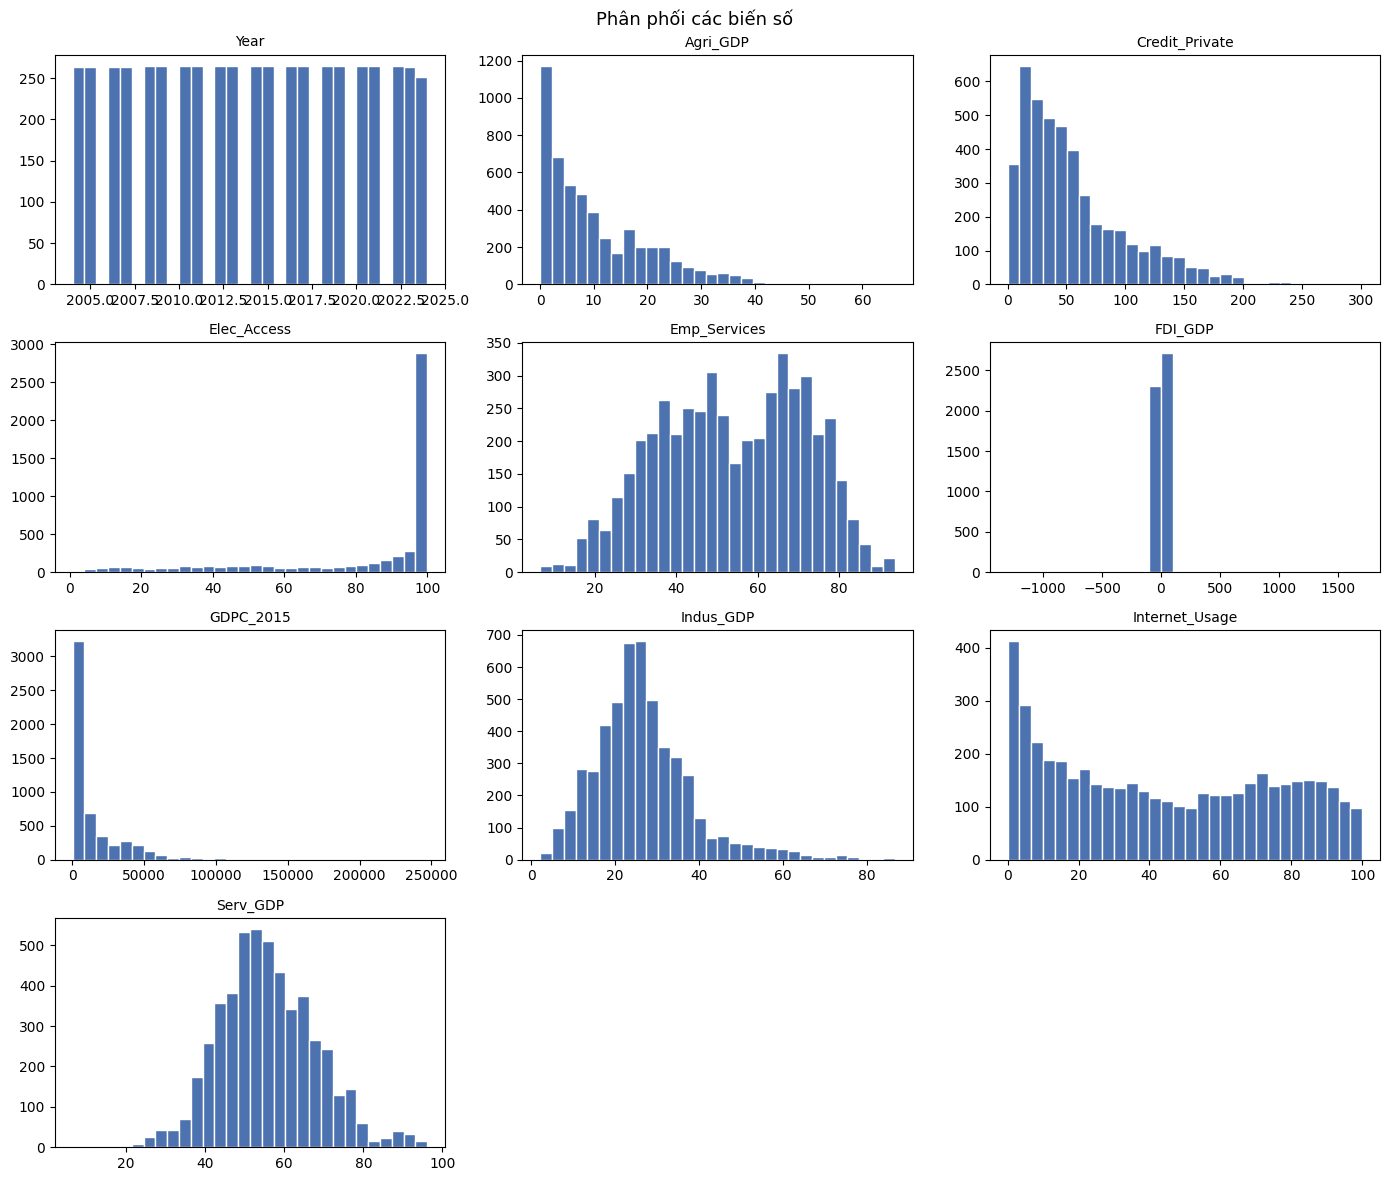

<Figure size 640x480 with 0 Axes>

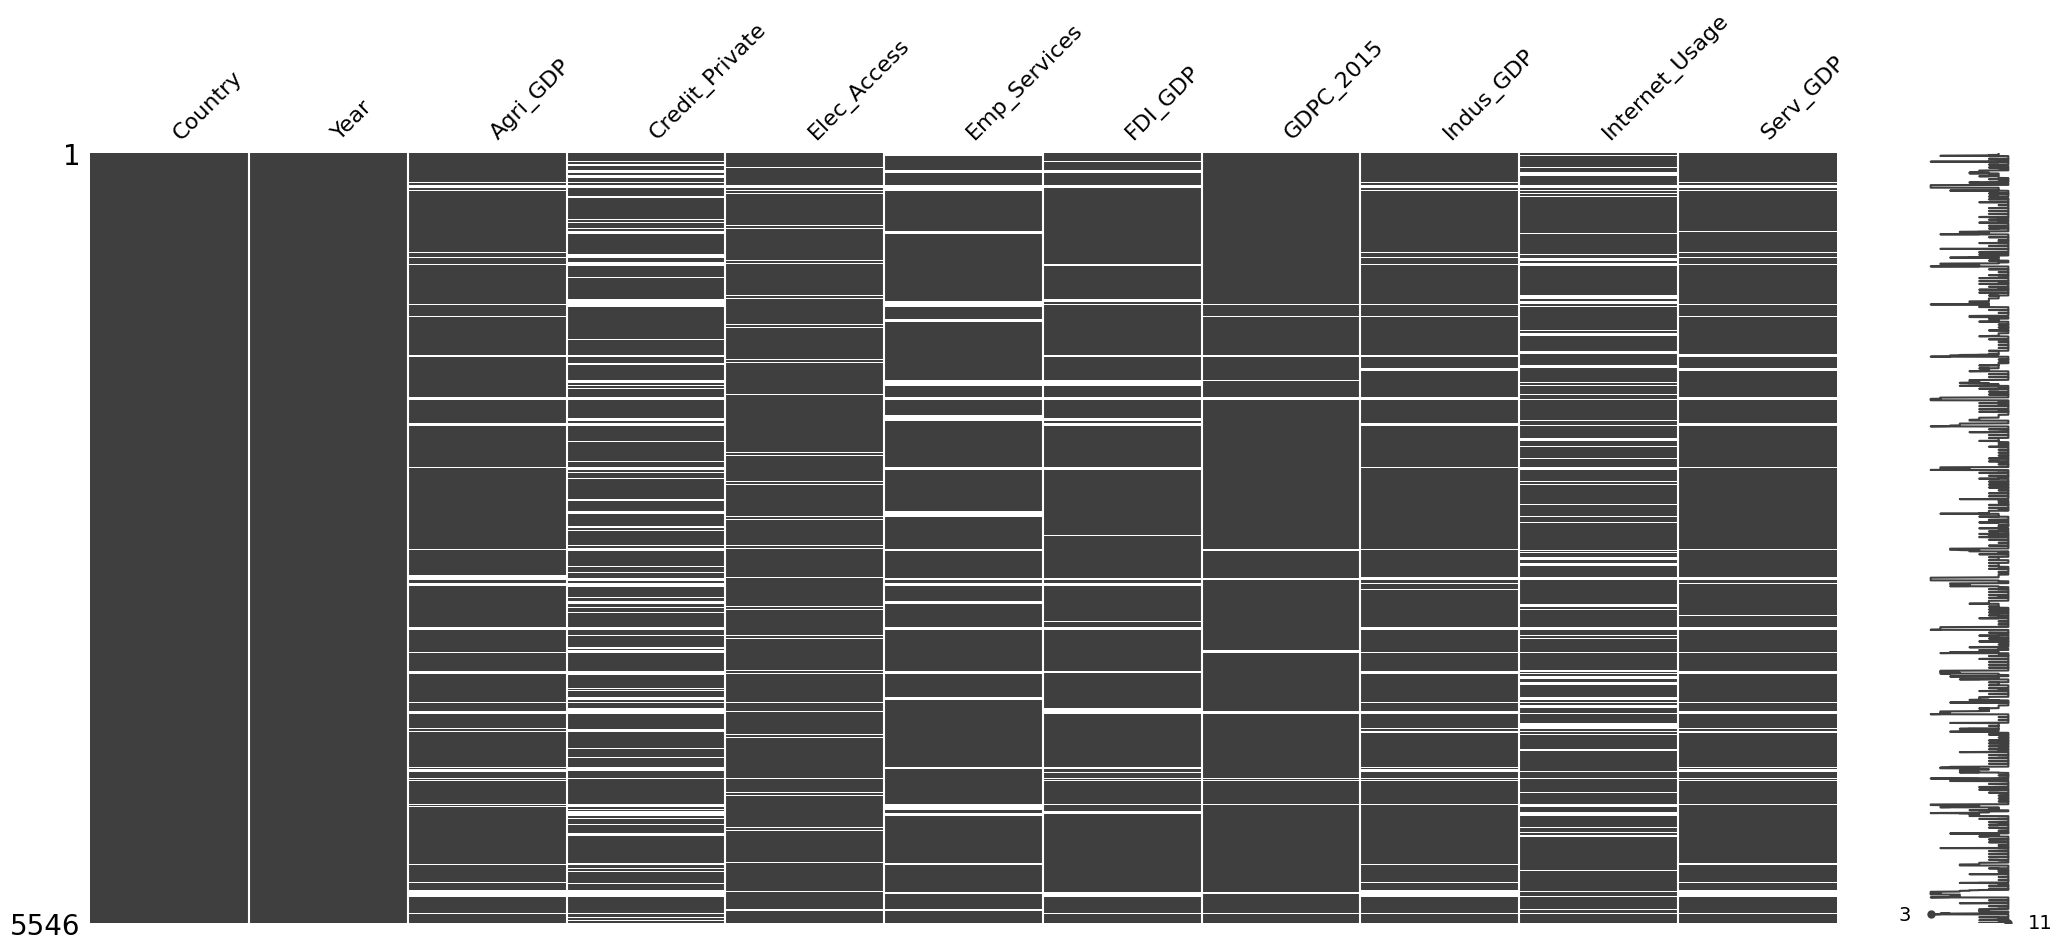

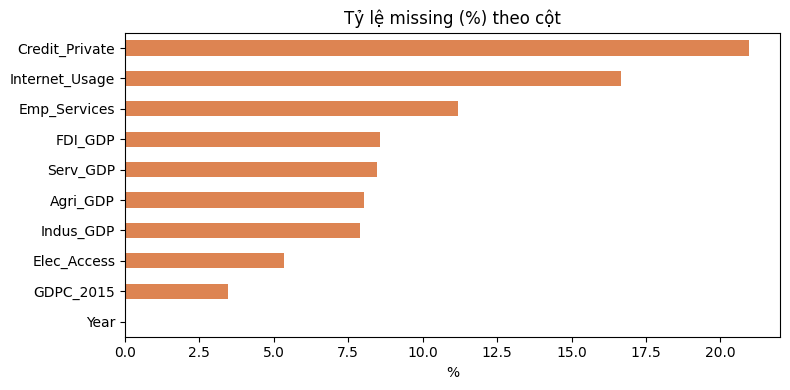

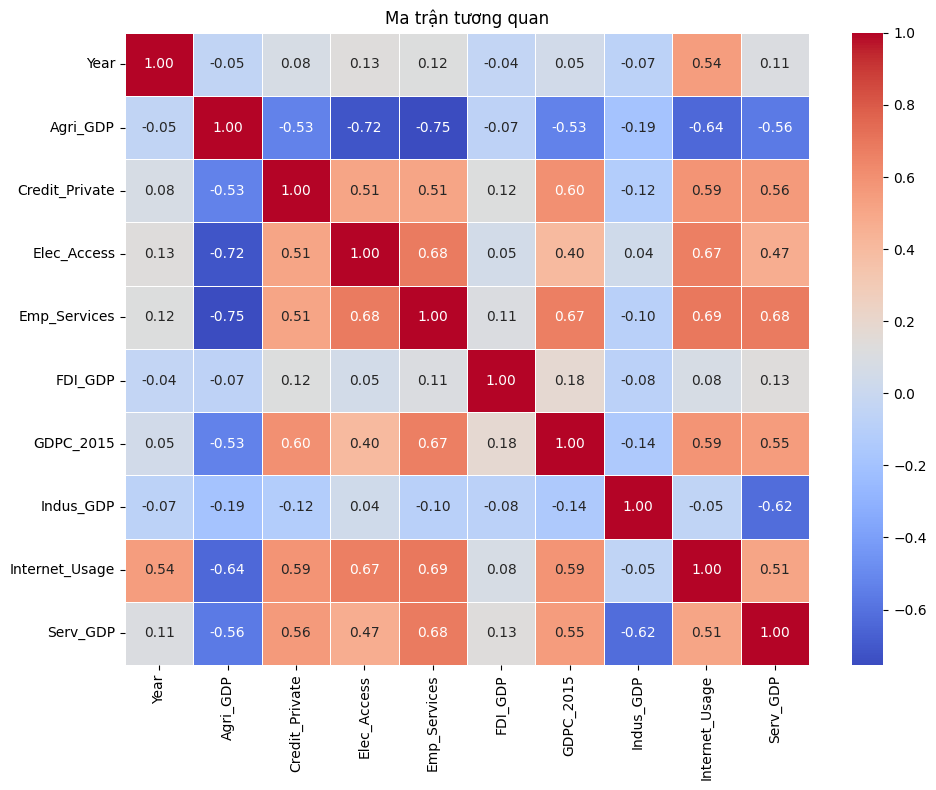


Sau khi loại quốc gia >50% missing: (5301, 11)
Còn lại 253 quốc gia

Missing sau xử lý: 0

Báo cáo outlier (trước khi winsorize):
           Cột  Outliers       Lower      Upper
          Year         0   1994.0000  2034.0000
      Agri_GDP        78    -18.4450    37.3984
Credit_Private       306    -49.1759   141.4899
   Elec_Access       318     22.2500   146.6500
  Emp_Services         0      2.0031   105.9273
       FDI_GDP       592     -4.3599    11.0105
     GDPC_2015       555 -22391.1832 42135.6619
     Indus_GDP       235     -0.1280    51.5460
Internet_Usage         0    -70.9099   157.6853
      Serv_GDP        85     23.5629    87.7410


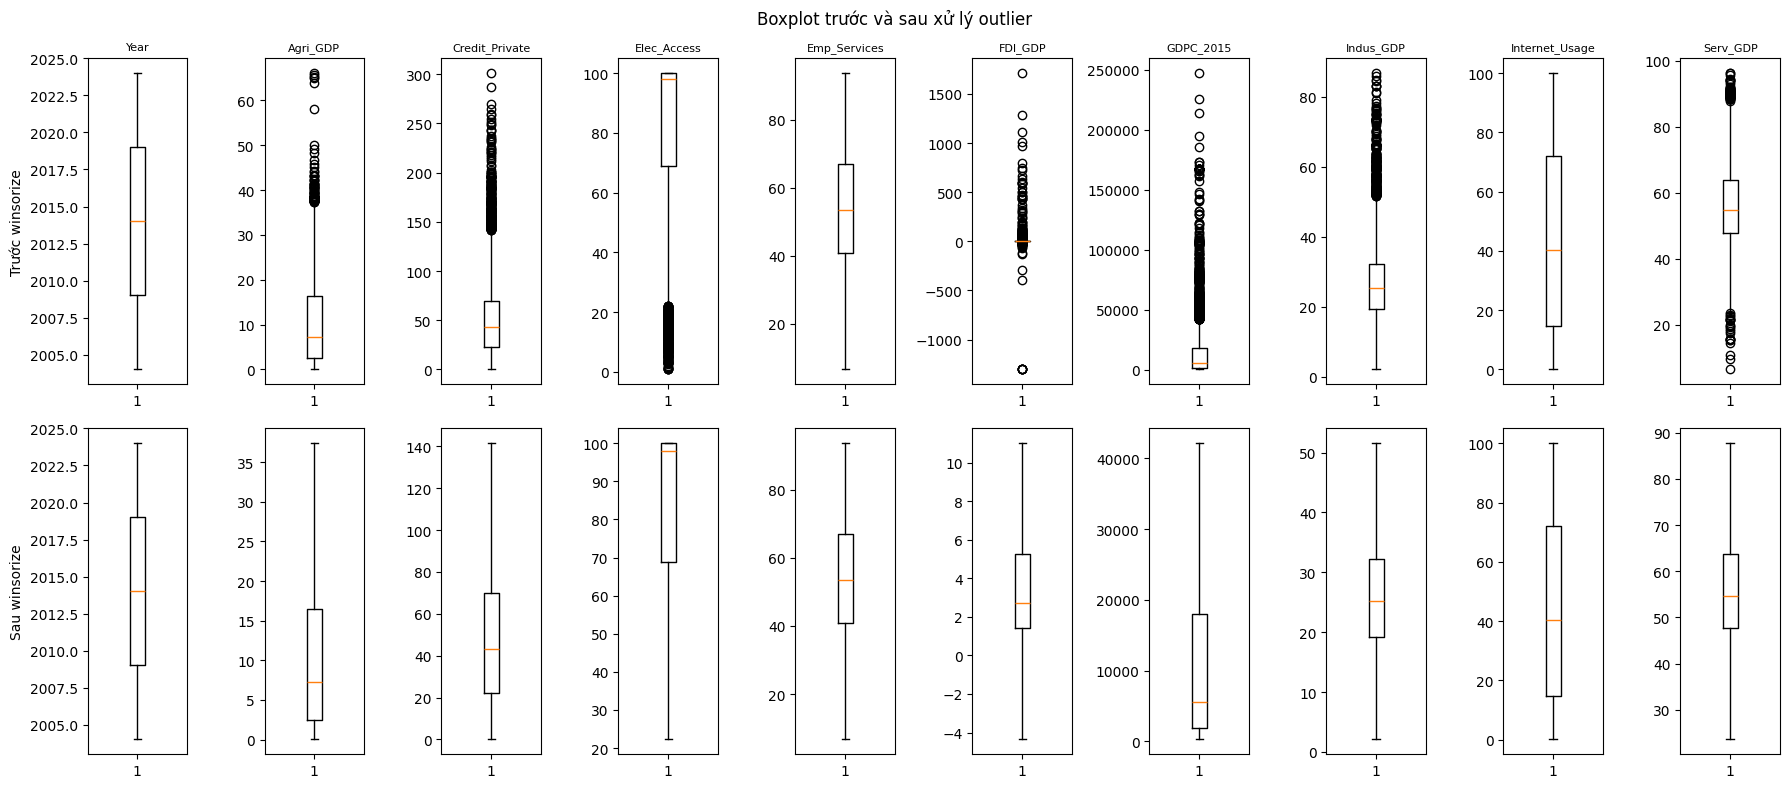

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno
warnings.filterwarnings('ignore')

df = pd.read_csv(r'../data/real data/world_bank.csv')
print(f"Kích thước dữ liệu gốc: {df.shape}")
print(f"Số quốc gia: {df['Country'].nunique()}")
print(f"Năm: {df['Year'].min()} – {df['Year'].max()}")
print()
print(df.head())
print()
print("Thống kê mô tả:")
print(df.describe())

df['Year'] = df['Year'].astype(int)
# num_cols = [c for c in df.select_dtypes('number').columns if c != 'Year']
num_cols = [c for c in df.select_dtypes('number').columns]

dup_rows    = df.duplicated().sum()
dup_keys    = df.duplicated(['Country', 'Year']).sum()
print(f"\nDuplicate rows: {dup_rows}")
print(f"Duplicate (Country, Year): {dup_keys}")

# 2.2 Missing values
missing_pct = df.isna().sum() / len(df) * 100
print("\nTỷ lệ missing (%) theo cột:")
print(missing_pct.round(2))

# 2.3 Quốc gia thiếu quá nhiều (> 50% tổng các cột số)
miss_by_country = (
    df.groupby('Country')[num_cols]
    .apply(lambda x: x.isna().mean().mean() * 100)
)
high_missing_countries = miss_by_country[miss_by_country > 50].index.tolist()
print(f"\nQuốc gia có >50% missing: {len(high_missing_countries)}")
print(high_missing_countries)

# ════════════════════════════════════════════
# EDA – PHÂN PHỐI & TƯƠNG QUAN
# ════════════════════════════════════════════

# Histogram
n, ncols = len(num_cols), 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Phân phối các biến số', fontsize=13)
plt.tight_layout()
plt.show()

# Heatmap missing
plt.figure()
msno.matrix(df)
plt.show()

# Tỷ lệ missing theo cột
plt.figure(figsize=(8, 4))
missing_pct[num_cols].sort_values().plot(kind='barh', color='#DD8452')
plt.title('Tỷ lệ missing (%) theo cột')
plt.xlabel('%')
plt.tight_layout()
plt.show()

# Ma trận tương quan
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════
# XỬ LÝ MISSING VALUES
# ════════════════════════════════════════════

# Loại quốc gia có > 50% missing (dữ liệu quá thưa, không tin cậy)
df_clean = df[~df['Country'].isin(high_missing_countries)].copy()
print(f"\nSau khi loại quốc gia >50% missing: {df_clean.shape}")
print(f"Còn lại {df_clean['Country'].nunique()} quốc gia")

# Nội suy theo thời gian trong từng quốc gia (linear interpolation)
#     Phù hợp vì dữ liệu là chuỗi thời gian panel
df_clean = df_clean.sort_values(['Country', 'Year'])
df_clean[num_cols] = (
    df_clean.groupby('Country')[num_cols]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

# Với các giá trị vẫn còn thiếu (đầu/cuối chuỗi hoặc quốc gia ít dữ liệu)
#     → Điền bằng median của từng năm (cross-sectional median)
for col in num_cols:
    year_median = df_clean.groupby('Year')[col].transform('median')
    df_clean[col] = df_clean[col].fillna(year_median)

# 4.4 Kiểm tra lại
remaining_missing = df_clean[num_cols].isna().sum().sum()
print(f"\nMissing sau xử lý: {remaining_missing}")

# ════════════════════════════════════════════
# XỬ LÝ OUTLIER (IQR, winsorize)
# ════════════════════════════════════════════
df_final = df_clean.copy()

outlier_report = []
for col in num_cols:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_final[col] < lower) | (df_final[col] > upper)).sum()
    outlier_report.append({'Cột': col, 'Outliers': n_outliers,
                           'Lower': round(lower, 4), 'Upper': round(upper, 4)})
    # Winsorize: cap tại ngưỡng IQR
    df_final[col] = df_final[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_report)
print("\nBáo cáo outlier (trước khi winsorize):")
print(outlier_df.to_string(index=False))

# Boxplot trước/sau
fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 8))
for i, col in enumerate(num_cols):
    axes[0, i].boxplot(df_clean[col].dropna())
    axes[0, i].set_title(col, fontsize=8)
    axes[1, i].boxplot(df_final[col].dropna())
axes[0, 0].set_ylabel('Trước winsorize')
axes[1, 0].set_ylabel('Sau winsorize')
plt.suptitle('Boxplot trước và sau xử lý outlier', fontsize=12)
plt.tight_layout()
plt.show()

# Xuất file đã điền khuyết logic
target = df_final['GDPC_2015']
df_final = df_final.drop(columns=['GDPC_2015'])
df_final['GDPC_2015'] = target.values
df_final.to_csv(r'../data/real data/world_bank_clean.csv', index=False)


In [33]:
features_with_missing = df.columns[df.isnull().any()].tolist()
print(f"\nCác features có missing values cần kiểm tra: {len(features_with_missing)}")

missing_indicators = pd.DataFrame()
for col in features_with_missing:
    missing_indicators[f'{col}_is_missing'] = df[col].isnull().astype(int)


Các features có missing values cần kiểm tra: 9


In [37]:
features_with_missing = [col for col in num_cols if df[col].isna().sum() > 0]
from scipy.stats import pearsonr, spearmanr
correlation_results = {}

for col in features_with_missing:
    data_complete = df[col].dropna()
    
    if len(data_complete) > 0:
        missing_indicator = missing_indicators[f'{col}_is_missing']
        
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        correlations = {}
        for other_col in numeric_cols:
            if other_col != col:
                valid_idx = ~df[other_col].isnull()
                
                if valid_idx.sum() > 2:
                    try:
                        corr, pval = spearmanr(missing_indicator[valid_idx], df.loc[valid_idx, other_col])
                        correlations[other_col] = {'correlation': corr, 'p_value': pval}
                    except:
                        pass
        
        high_corr = {k: v for k, v in correlations.items() if abs(v['correlation']) > 0.3 and v['p_value'] < 0.05}
        
        if high_corr:
            correlation_results[col] = high_corr
    print(correlation_results)

{}
{}
{'Elec_Access': {'Year': {'correlation': np.float64(0.3211405325636751), 'p_value': np.float64(3.0699769533273595e-133)}}}
{'Elec_Access': {'Year': {'correlation': np.float64(0.3211405325636751), 'p_value': np.float64(3.0699769533273595e-133)}}, 'Emp_Services': {'Indus_GDP': {'correlation': np.float64(-0.34333209434357087), 'p_value': np.float64(2.8024055318341154e-141)}, 'Serv_GDP': {'correlation': np.float64(0.31424506202041197), 'p_value': np.float64(9.856376953427565e-117)}}}
{'Elec_Access': {'Year': {'correlation': np.float64(0.3211405325636751), 'p_value': np.float64(3.0699769533273595e-133)}}, 'Emp_Services': {'Indus_GDP': {'correlation': np.float64(-0.34333209434357087), 'p_value': np.float64(2.8024055318341154e-141)}, 'Serv_GDP': {'correlation': np.float64(0.31424506202041197), 'p_value': np.float64(9.856376953427565e-117)}}}
{'Elec_Access': {'Year': {'correlation': np.float64(0.3211405325636751), 'p_value': np.float64(3.0699769533273595e-133)}}, 'Emp_Services': {'Indus_

In [38]:
from scipy.stats import ks_2samp, mannwhitneyu

mnar_results = {}

for col in features_with_missing:
    data_with_value = df[df[col].notna()][col]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(data_with_value) > 0:
        missing_idx = df[col].isna()
        not_missing_idx = ~missing_idx
        different_distributions = []
        
        for other_col in numeric_cols:
            if other_col != col and ~df[other_col].isna().all():
                try:
                    group_with_value = df[not_missing_idx][other_col].dropna()
                    group_missing = df[missing_idx][other_col].dropna()
                    
                    if len(group_with_value) > 2 and len(group_missing) > 2:
                        stat, pval = mannwhitneyu(group_with_value, group_missing)
                        
                        if pval < 0.05: 
                            mean_with = group_with_value.mean()
                            mean_missing = group_missing.mean()
                            different_distributions.append({
                                'feature': other_col,
                                'p_value': pval,
                                'mean_with_value': mean_with,
                                'mean_missing': mean_missing
                            })
                except:
                    pass
        
        if different_distributions:
            print(f"    ✓ Tìm thấy {len(different_distributions)} features có phân phối khác biệt (MNAR indicator):")
            for item in sorted(different_distributions, key=lambda x: x['p_value'])[:5]:  # Top 5
                print(f"      • {item['feature']}: mean(có_giá_trị)={item['mean_with_value']:.2f}, mean(missing)={item['mean_missing']:.2f}, p={item['p_value']:.4f}")
            mnar_results[col] = different_distributions
        else:
            print(f"    • Không tìm thấy phân phối khác biệt (có thể là MAR hoặc MCAR)")
        print()

    ✓ Tìm thấy 5 features có phân phối khác biệt (MNAR indicator):
      • Serv_GDP: mean(có_giá_trị)=55.48, mean(missing)=88.45, p=0.0000
      • GDPC_2015: mean(có_giá_trị)=13595.68, mean(missing)=39284.36, p=0.0000
      • Indus_GDP: mean(có_giá_trị)=26.73, mean(missing)=11.35, p=0.0000
      • Elec_Access: mean(có_giá_trị)=81.60, mean(missing)=86.85, p=0.0000
      • Emp_Services: mean(có_giá_trị)=53.36, mean(missing)=61.13, p=0.0000

    ✓ Tìm thấy 8 features có phân phối khác biệt (MNAR indicator):
      • Elec_Access: mean(có_giá_trị)=79.97, mean(missing)=90.20, p=0.0000
      • GDPC_2015: mean(có_giá_trị)=12720.32, mean(missing)=24762.03, p=0.0000
      • Serv_GDP: mean(có_giá_trị)=55.01, mean(missing)=59.69, p=0.0000
      • Indus_GDP: mean(có_giá_trị)=26.92, mean(missing)=24.88, p=0.0000
      • Agri_GDP: mean(có_giá_trị)=10.61, mean(missing)=9.69, p=0.0000

    ✓ Tìm thấy 4 features có phân phối khác biệt (MNAR indicator):
      • Year: mean(có_giá_trị)=2013.52, mean(missing

In [39]:
classification = {
    'MAR': [],      
    'MNAR': [],     
    'MCAR': []     
}

for col in features_with_missing:
    is_mar = col in correlation_results
    is_mnar = col in mnar_results
    
    if is_mar and is_mnar:
        classification['MAR'].append(f"{col} (có tương quan + phân phối khác)")
    elif is_mar:
        classification['MAR'].append(col)
    elif is_mnar:
        classification['MNAR'].append(col)
    else:
        classification['MCAR'].append(col)


if classification['MAR']:
    print(f"▸ MAR (Missing At Random) - {len(classification['MAR'])} features:")
    for feat in classification['MAR']:
        print(f"    • {feat}")

if classification['MNAR']:
    print(f"\n▸ MNAR (Missing Not At Random) - {len(classification['MNAR'])} features:")
    for feat in classification['MNAR']:
        print(f"    • {feat}")
    

if classification['MCAR']:
    print(f"\n▸ MCAR (Missing Completely At Random) - {len(classification['MCAR'])} features:")
    for feat in classification['MCAR']:
        print(f"    • {feat}")


▸ MAR (Missing At Random) - 2 features:
    • Elec_Access (có tương quan + phân phối khác)
    • Emp_Services (có tương quan + phân phối khác)

▸ MNAR (Missing Not At Random) - 7 features:
    • Agri_GDP
    • Credit_Private
    • FDI_GDP
    • GDPC_2015
    • Indus_GDP
    • Internet_Usage
    • Serv_GDP


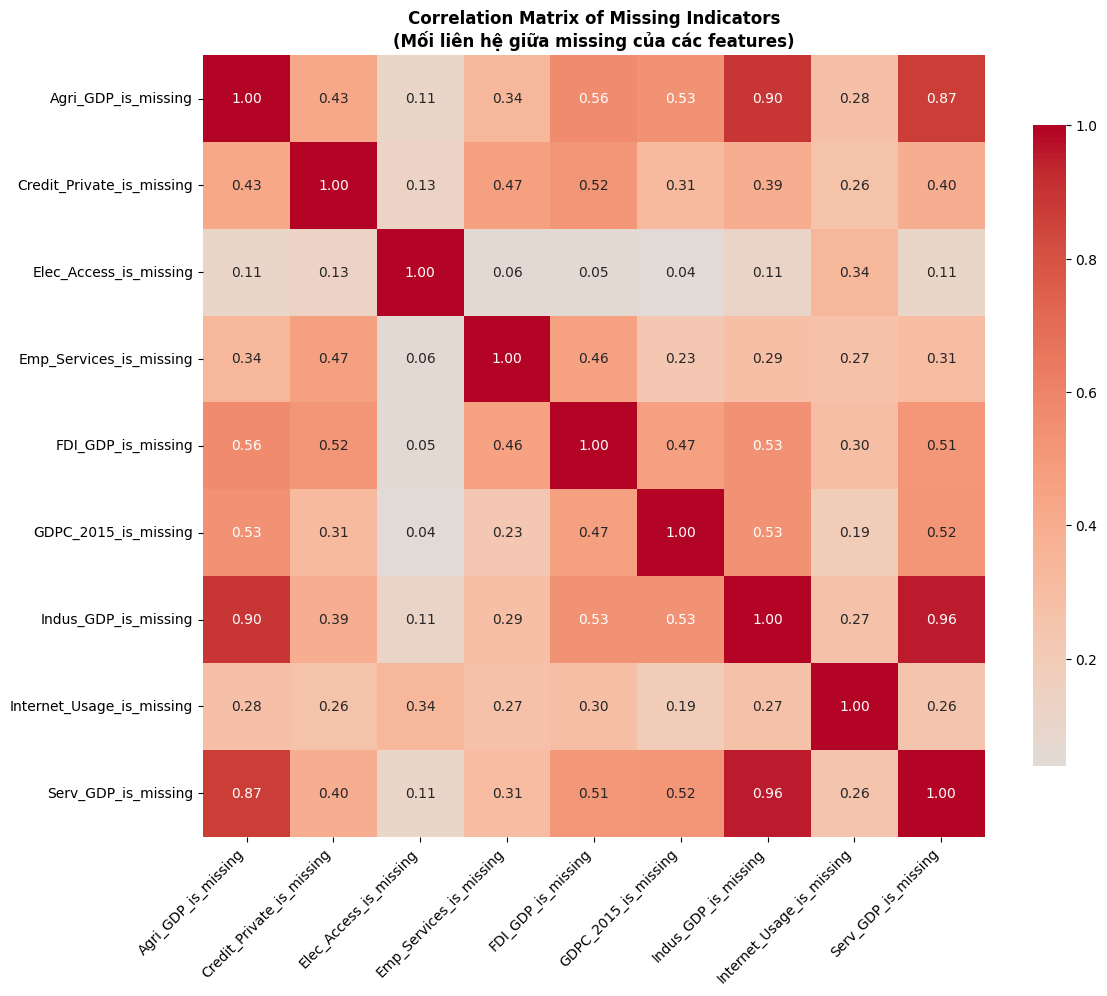

In [40]:
corr_matrix = missing_indicators.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix of Missing Indicators\n(Mối liên hệ giữa missing của các features)', 
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    data_numeric = df[numeric_cols].copy()

    data_for_vif = data_numeric.dropna()
    
    print(f"\n💡 Tính VIF cho {len(numeric_cols)} features numeric:")
    print(f"  Dữ liệu để tính VIF: {len(data_for_vif)} rows (đã xóa {len(data_numeric) - len(data_for_vif)} rows có missing)")
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = numeric_cols
    vif_data["VIF"] = [variance_inflation_factor(data_for_vif.values, i) 
                       for i in range(len(numeric_cols))]
    vif_data = vif_data.sort_values("VIF", ascending=False)
    
    print(vif_data.to_string(index=False))    
    high_vif_features = vif_data[vif_data["VIF"] > 5]["Feature"].tolist()
    
    if high_vif_features:
        print(f"\n✓ {len(high_vif_features)} features có VIF > 5 (Multicollinearity cao):")
        for feat in high_vif_features:
            vif_val = vif_data[vif_data["Feature"] == feat]["VIF"].values[0]
            print(f"    • {feat}: VIF = {vif_val:.2f} → Likely MAR")
    else:
        print(f"\n• Không có features có VIF > 5")
        print(f"  → Có thể là MCAR hoặc MNAR")
    
    for feat in high_vif_features:
        if feat not in correlation_results:
            correlation_results[feat] = [f"VIF = {vif_data[vif_data['Feature'] == feat]['VIF'].values[0]:.2f}"]
        
except ImportError:
    print("⚠ Cài đặt statsmodels để tính VIF...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
    print("✓ Đã cài đặt statsmodels")
except Exception as e:
    print(f"Lỗi: {e}")


💡 Tính VIF cho 10 features numeric:
  Dữ liệu để tính VIF: 3568 rows (đã xóa 1978 rows có missing)
       Feature        VIF
          Year 479.261151
      Serv_GDP 202.659990
  Emp_Services  44.042585
     Indus_GDP  36.413114
   Elec_Access  26.515449
      Agri_GDP  16.185606
Internet_Usage   8.737206
Credit_Private   5.485065
     GDPC_2015   3.714334
       FDI_GDP   1.094260

✓ 8 features có VIF > 5 (Multicollinearity cao):
    • Year: VIF = 479.26 → Likely MAR
    • Serv_GDP: VIF = 202.66 → Likely MAR
    • Emp_Services: VIF = 44.04 → Likely MAR
    • Indus_GDP: VIF = 36.41 → Likely MAR
    • Elec_Access: VIF = 26.52 → Likely MAR
    • Agri_GDP: VIF = 16.19 → Likely MAR
    • Internet_Usage: VIF = 8.74 → Likely MAR
    • Credit_Private: VIF = 5.49 → Likely MAR


In [26]:
def analyze_and_filter_correlations(df, target_col, threshold=0.8):
    corr_matrix = df.corr().corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Tìm các cột có tương quan > threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # 3. Phân tích độ tương quan với biến mục tiêu (target)
    target_corr = corr_matrix[target_col].sort_values(ascending=False)
    
    print(f"--- Đề xuất loại bỏ do tương quan quá cao (> {threshold}): ---")
    print(to_drop)
    
    print(f"\n--- Độ tương quan với '{target_col}': ---")
    print(target_corr.drop(target_col))
    
    return to_drop, target_corr
to_drop, corr_with_target = analyze_and_filter_correlations(df_final.drop(columns=['Country']), target_col='Serv_GDP')


--- Đề xuất loại bỏ do tương quan quá cao (> 0.8): ---
['Credit_Private', 'Elec_Access', 'GDPC_2015', 'Internet_Usage', 'Serv_GDP']

--- Độ tương quan với 'Serv_GDP': ---
GDPC_2015         0.841509
Credit_Private    0.802710
Internet_Usage    0.768404
Agri_GDP          0.750561
Elec_Access       0.749143
Indus_GDP         0.669650
FDI_GDP           0.233548
Year              0.166484
Name: Serv_GDP, dtype: float64


In [ ]:
# Bỏ cột tương quan cao
df_final_reduced = df_final.drop(columns=to_drop)
print(f"\nKích thước sau khi loại bỏ cột tương quan cao: {df_final_reduced.shape}")
df_final_reduced.to_csv('world_bank_clean_reduced.csv', index=False)


Kích thước sau khi loại bỏ cột tương quan cao: (5301, 5)


=> Không cần lọc cột